# Covariant Informative Showcase

A covariant walkthrough built on the V3-F09 analysis surface. The notebook reuses
`generate_covariant_benchmark()` and `run_covariant_analysis()` to compare pairwise,
conditional, directional, and causal evidence on the same synthetic system.

Sections:
- A. Why covariant
- B. Data setup
- C. Baseline: CrossAMI + CrosspAMI
- D. GCMI
- E. Transfer entropy
- F. PCMCI+
- G. PCMCI-AMI
- H. Unified interpretation table


## Setup

The benchmark section runs one full covariant analysis bundle and then reuses the
result across the method sections. Auxiliary checks are limited to a monotone-transform
comparison for GCMI and an F09-style directional pair for TE.

In [1]:
%matplotlib inline

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from forecastability.reporting.covariant_walkthrough import (
    causal_parent_frame,
    conditioning_scope_frame,
    driver_role_frame,
    save_causal_parent_heatmap,
    save_directionality_plot,
    save_metric_heatmap,
    save_phase0_overview,
    summary_table_frame,
    synthetic_benchmark_role_frame,
    write_frame_csv,
)
from forecastability.services.covariant_interpretation_service import interpret_covariant_bundle
from forecastability.use_cases.run_covariant_analysis import run_covariant_analysis
from forecastability.utils.synthetic import generate_covariant_benchmark, generate_directional_pair

pd.set_option("display.max_rows", 40)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
pd.set_option("display.precision", 4)

OUTPUT_ROOT = Path("outputs/notebooks/walkthroughs/01_covariant_informative_showcase")
FIG_DIR = OUTPUT_ROOT / "figures"
TABLE_DIR = OUTPUT_ROOT / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
MAX_LAG = 5
N_SURROGATES = 99
N_BENCHMARK = 1500


## A — Why covariant

Unconditional pairwise dependence is useful for screening, but it is not enough for
multivariate driver selection. In the synthetic benchmark, some candidate drivers are
redundant, some are mediated through stronger parents, and one parent is purely
contemporaneous. A covariant workflow therefore needs multiple views:

- `cross_ami`: pairwise lagged dependence.
- `cross_pami`: dependence that survives conditioning on the target's own history.
- `transfer_entropy`: directional information flow.
- `gcmi`: copula-based dependence that is robust to monotone marginal transforms.
- `pcmci` and `pcmci_ami`: graph-based causal filtering.

The notebook keeps those views on the same target so the differences are visible in
one place instead of as isolated examples.

In [3]:
display(
    Markdown(
        "**Working rule:** sections C through H reuse a single full bundle from "
        "`run_covariant_analysis()`. The only extra computation outside that bundle is "
        "a small monotone-transform check for GCMI and an F09-style TE directionality pair."
    )
)

**Working rule:** sections C through H reuse a single full bundle from `run_covariant_analysis()`. The only extra computation outside that bundle is a small monotone-transform check for GCMI and an F09-style TE directionality pair.

## B — Data setup

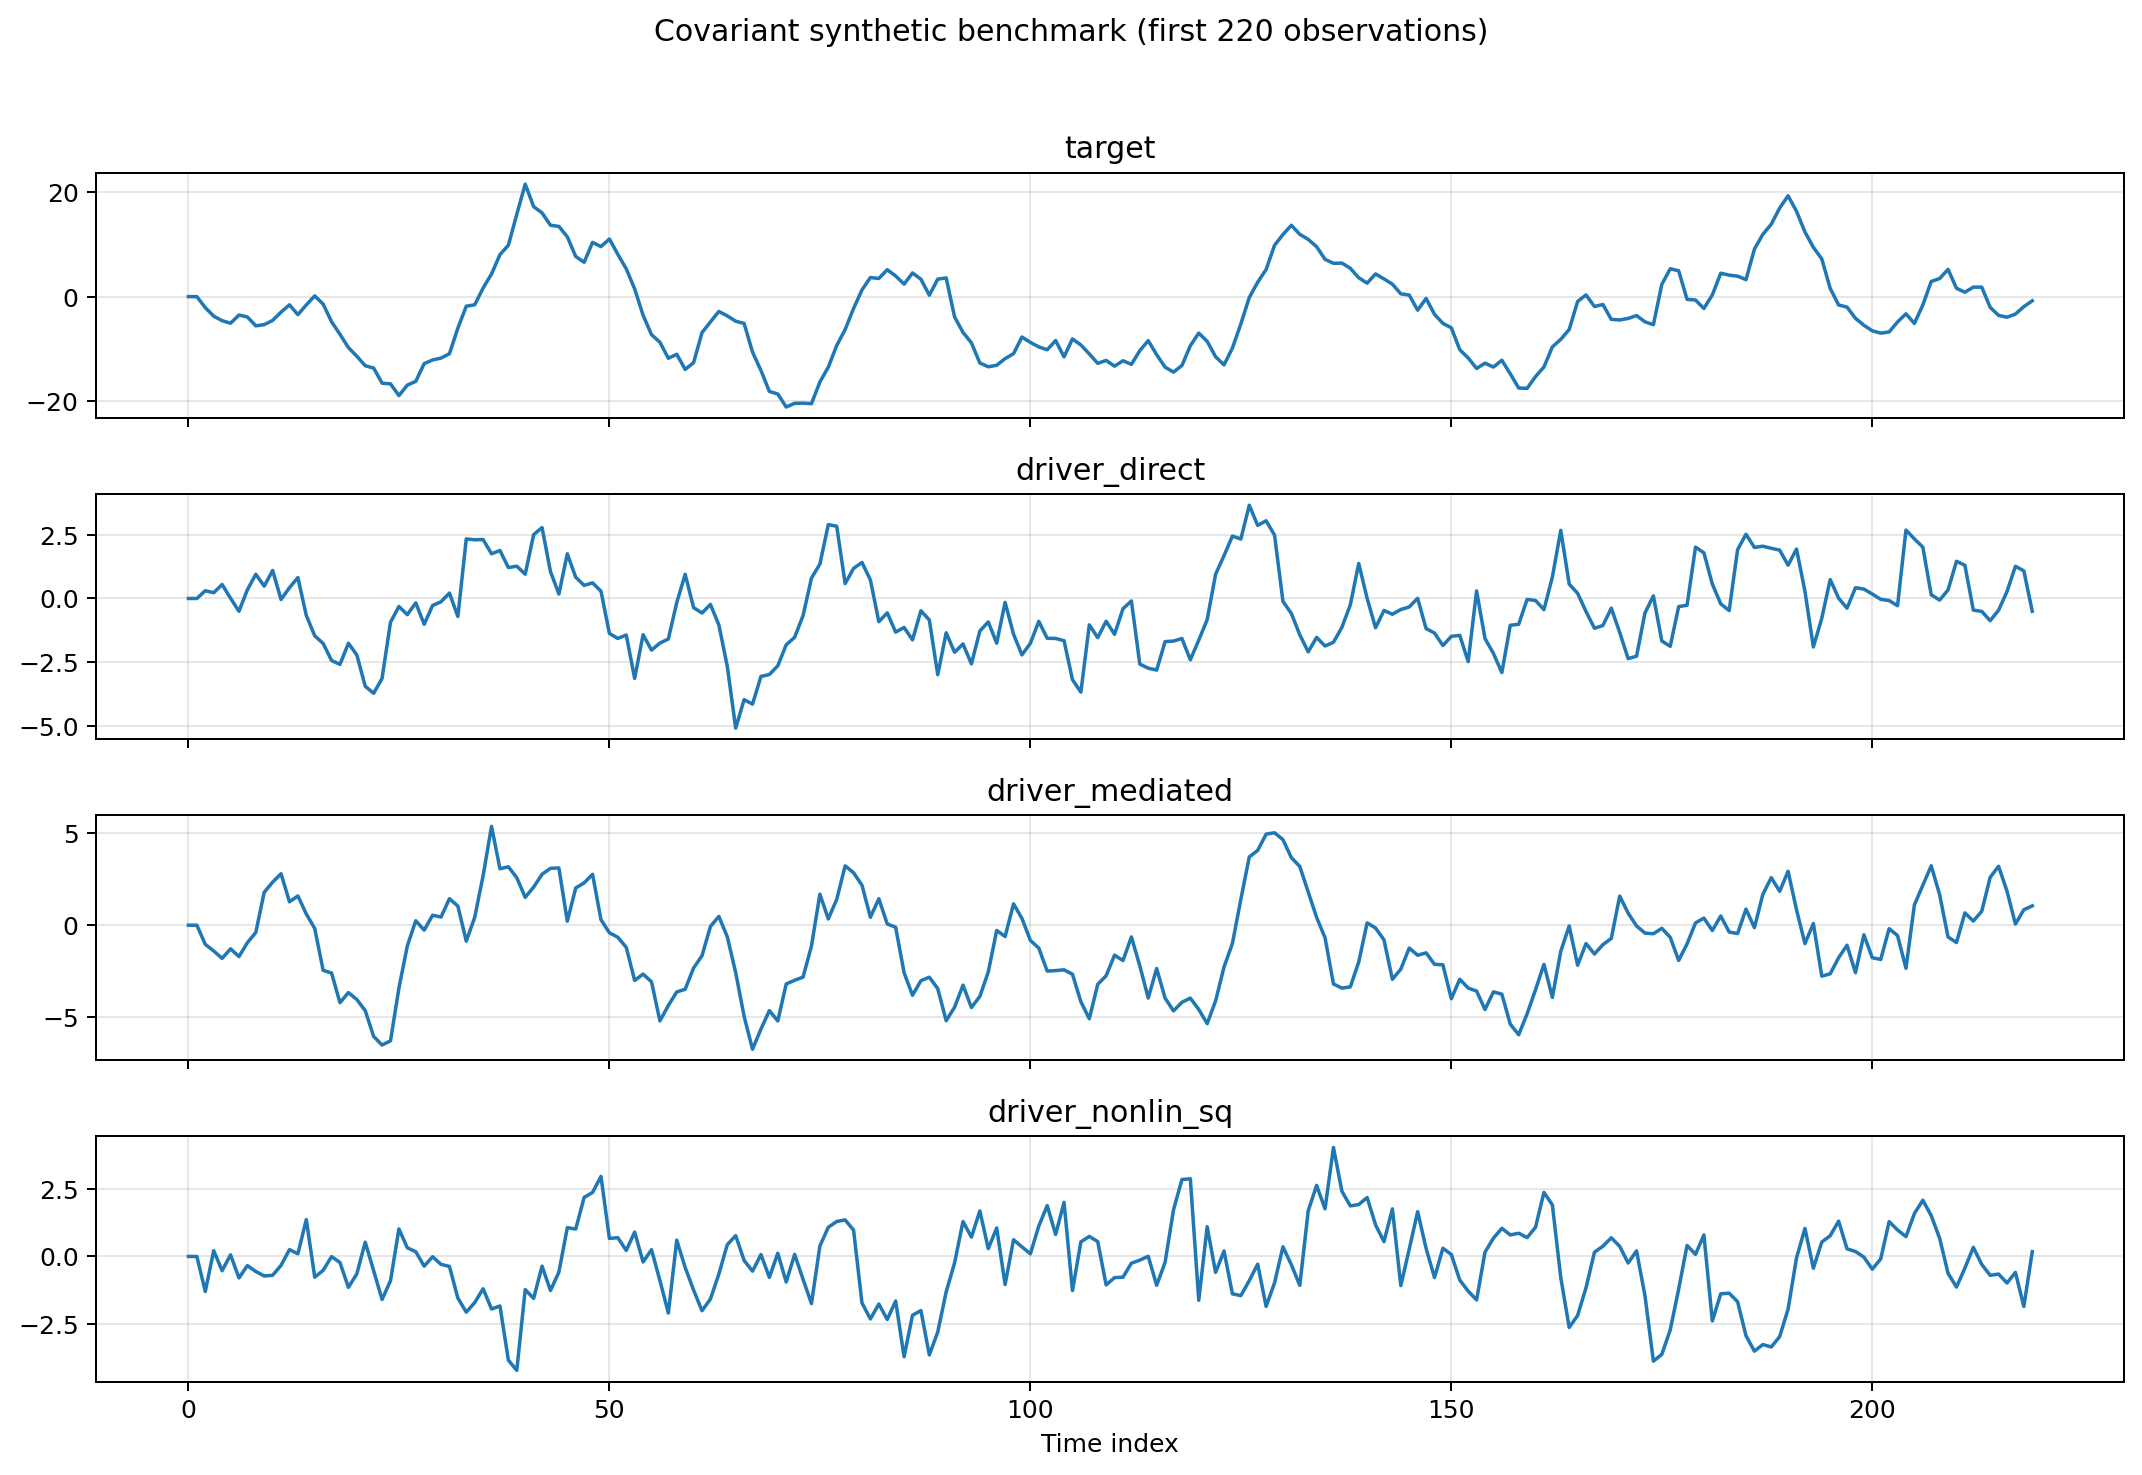

,driver,ground_truth_role,canonical_lag
0,driver_direct,Lagged linear direct parent,2
1,driver_mediated,Lagged parent with mediated structure,1
2,driver_redundant,Strong but redundant covariate,not a parent
3,driver_noise,AR(1) noise control,not a parent
4,driver_contemp,Contemporaneous parent,0
5,driver_nonlin_sq,Quadratic nonlinear parent,1
6,driver_nonlin_abs,Absolute-value nonlinear parent,1


In [4]:
benchmark_df = generate_covariant_benchmark(n=N_BENCHMARK, seed=SEED)
target = benchmark_df["target"].to_numpy()
drivers = {column: benchmark_df[column].to_numpy() for column in benchmark_df.columns if column != "target"}

role_frame = synthetic_benchmark_role_frame()
write_frame_csv(role_frame, output_path=TABLE_DIR / "section_b_ground_truth_roles.csv")

window = 220
series_path = FIG_DIR / "section_b_benchmark_series.png"
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
plot_columns = ["target", "driver_direct", "driver_mediated", "driver_nonlin_sq"]
for ax, column in zip(axes, plot_columns, strict=True):
    ax.plot(benchmark_df[column].iloc[:window].to_numpy(), linewidth=1.4)
    ax.set_title(column)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Time index")
fig.suptitle("Covariant synthetic benchmark (first 220 observations)", y=1.02)
fig.tight_layout()
fig.savefig(series_path, dpi=180, bbox_inches="tight")
plt.close(fig)

display(Image(filename=str(series_path)))
display(role_frame)

In [5]:
display(
    Markdown(
        "The synthetic system mixes direct, mediated, redundant, contemporaneous, and "
        "nonlinear drivers on purpose. That makes it possible to check which methods are "
        "merely ranking pairwise strength and which methods are actually filtering toward "
        "structural parents."
    )
)

The synthetic system mixes direct, mediated, redundant, contemporaneous, and nonlinear drivers on purpose. That makes it possible to check which methods are merely ranking pairwise strength and which methods are actually filtering toward structural parents.

## Shared full covariant run

This analysis takes up to 2-3 minutes

In [6]:
bundle_all = run_covariant_analysis(
    target,
    drivers,
    max_lag=MAX_LAG,
    n_surrogates=N_SURROGATES,
    random_state=SEED,
)
summary_all = summary_table_frame(bundle_all)
write_frame_csv(summary_all, output_path=TABLE_DIR / "section_shared_full_summary.csv")

skipped_optional = bundle_all.metadata.get("skipped_optional_methods")
if skipped_optional:
    display(Markdown(f"**Optional methods skipped:** `{skipped_optional}`"))
else:
    display(Markdown("**All six methods were available in this run.**"))

summary_all.head()

**All six methods were available in this run.**

,target,driver,lag,cross_ami,cross_pami,transfer_entropy,gcmi,pcmci_link,pcmci_ami_parent,significance,rank,interpretation_tag,lagged_exog_conditioning
0,target,driver_mediated,2,0.7171,0.0332,0.1165,1.0399,NaN,False,above_band,1,probably_mediated,"{'cross_ami': 'none', 'cross_pami': 'target_on..."
1,target,driver_mediated,3,0.7095,0.0000,0.0000,0.9954,NaN,False,above_band,2,probably_mediated,"{'cross_ami': 'none', 'cross_pami': 'target_on..."
2,target,driver_redundant,1,0.6584,0.6584,0.6584,0.8300,NaN,False,above_band,3,directional_informative,"{'cross_ami': 'none', 'cross_pami': 'target_on..."
3,target,driver_mediated,1,0.6270,0.6270,0.6270,0.8985,-->,True,above_band,4,causal_confirmed,"{'cross_ami': 'none', 'cross_pami': 'target_on..."
4,target,driver_mediated,4,0.5930,0.0151,0.0067,0.8291,NaN,False,above_band,5,probably_mediated,"{'cross_ami': 'none', 'cross_pami': 'target_on..."


## C — Baseline: CrossAMI + CrosspAMI

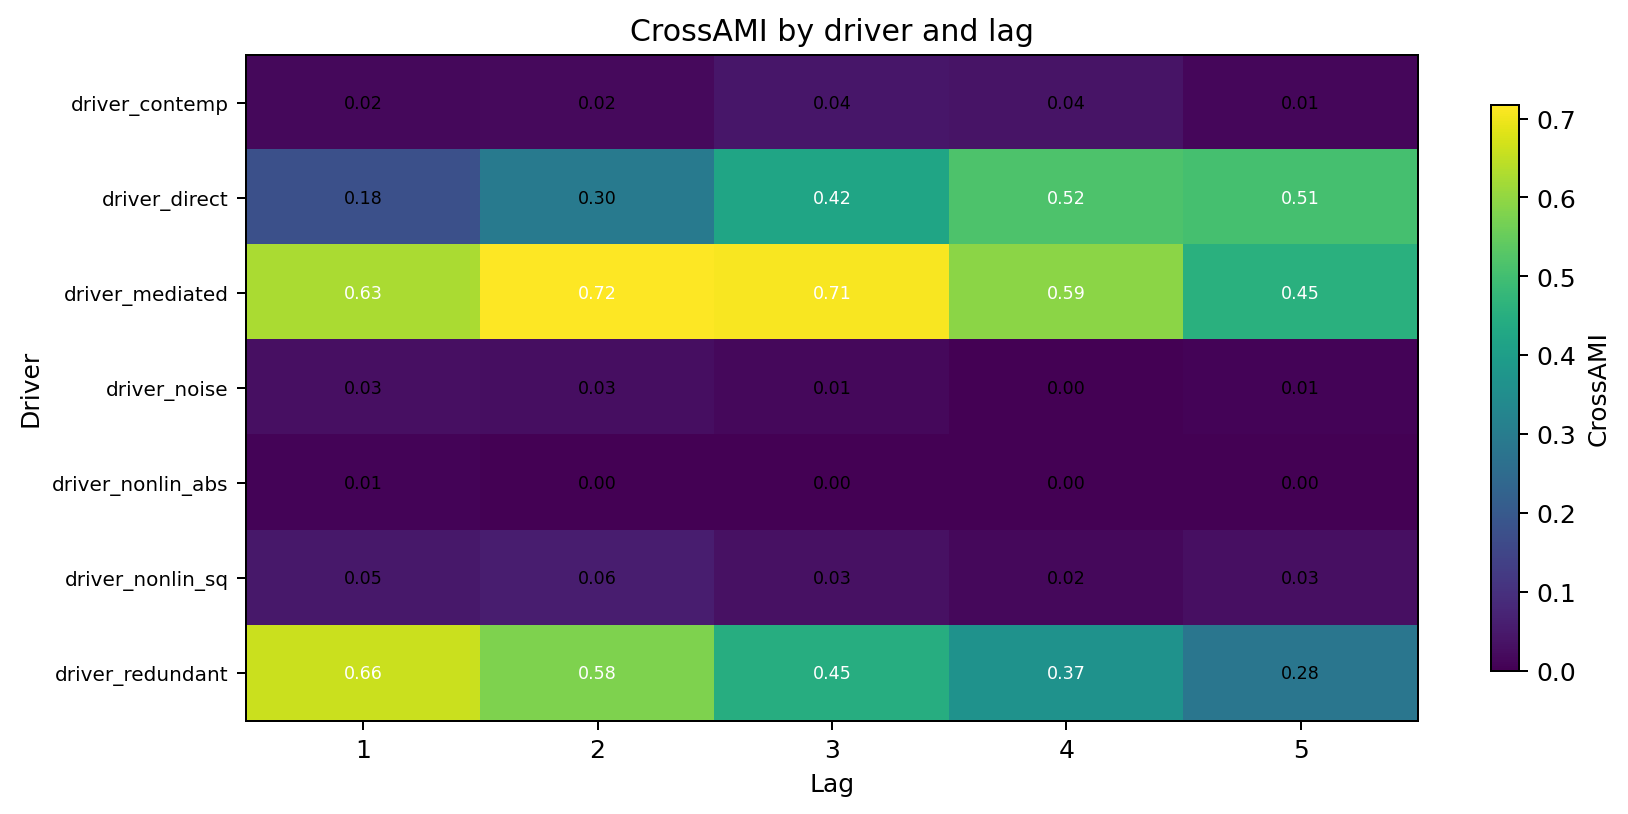

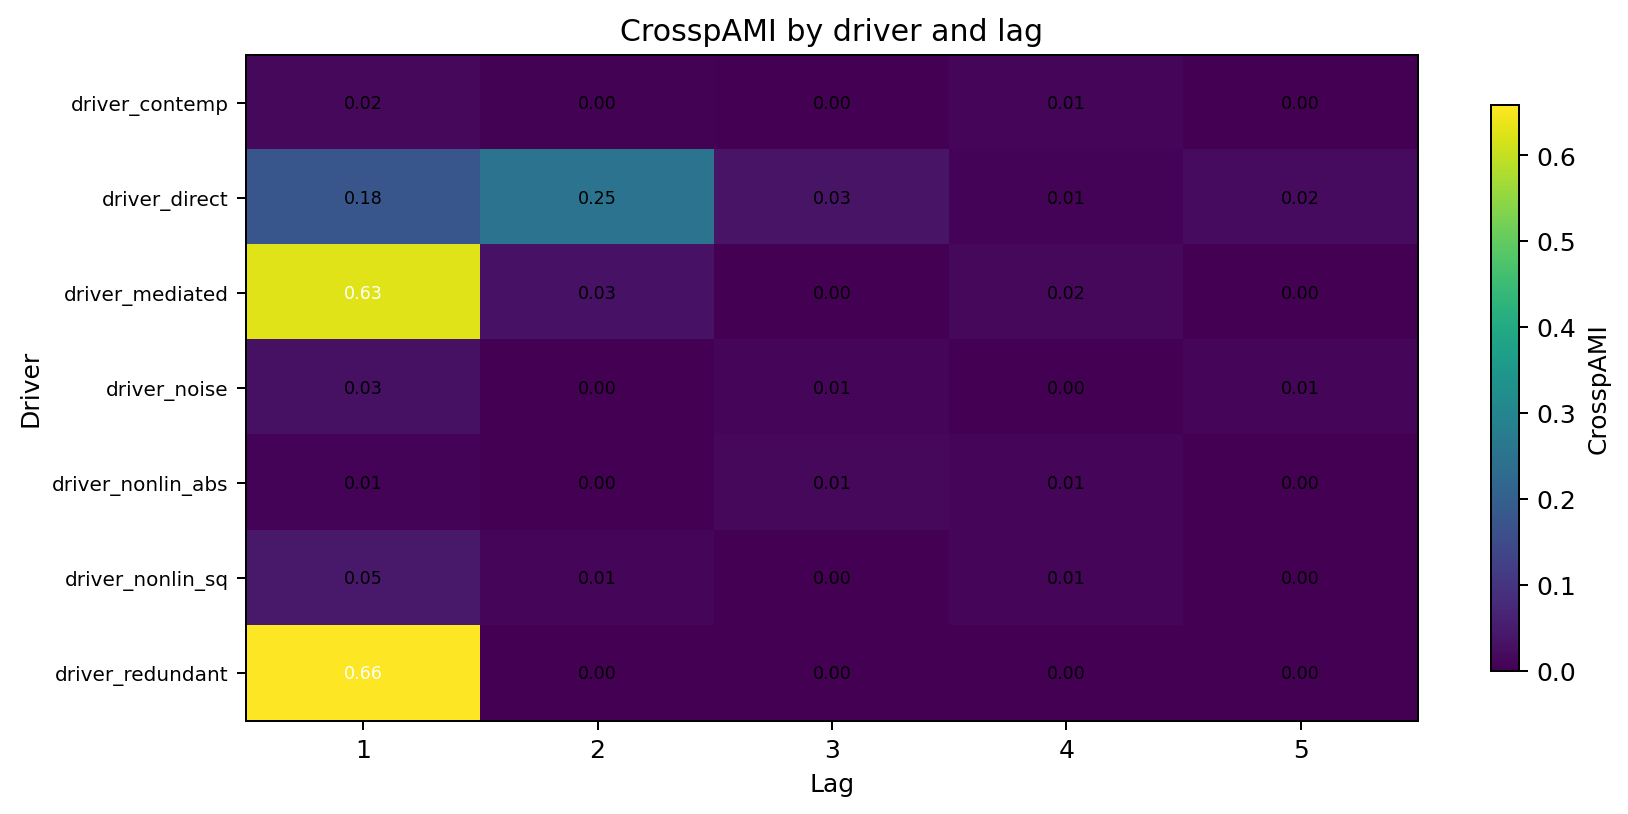

,driver,lag,cross_ami,cross_pami,significance,rank,interpretation_tag,pami_to_ami
0,driver_mediated,2,0.7171,0.0332,above_band,1,probably_mediated,0.0463
1,driver_mediated,3,0.7095,0.0000,above_band,2,probably_mediated,0.0000
2,driver_redundant,1,0.6584,0.6584,above_band,3,directional_informative,1.0000
3,driver_mediated,1,0.6270,0.6270,above_band,4,causal_confirmed,1.0000
4,driver_mediated,4,0.5930,0.0151,above_band,5,probably_mediated,0.0254
5,driver_redundant,2,0.5784,0.0016,above_band,6,probably_mediated,0.0028
6,driver_direct,4,0.5161,0.0075,above_band,7,probably_mediated,0.0145
7,driver_direct,5,0.5055,0.0197,above_band,8,probably_mediated,0.0391
8,driver_mediated,5,0.4544,0.0000,above_band,9,probably_mediated,0.0000
9,driver_redundant,3,0.4471,0.0000,above_band,10,probably_mediated,0.0000


In [7]:
cross_ami_path = FIG_DIR / "section_c_cross_ami_heatmap.png"
cross_pami_path = FIG_DIR / "section_c_cross_pami_heatmap.png"

cross_ami_grid = save_metric_heatmap(
    bundle_all,
    metric="cross_ami",
    output_path=cross_ami_path,
    title="CrossAMI by driver and lag",
)
cross_pami_grid = save_metric_heatmap(
    bundle_all,
    metric="cross_pami",
    output_path=cross_pami_path,
    title="CrosspAMI by driver and lag",
)

baseline_view = summary_all[
    ["driver", "lag", "cross_ami", "cross_pami", "significance", "rank", "interpretation_tag"]
].copy()
baseline_view["pami_to_ami"] = np.where(
    baseline_view["cross_ami"].gt(0.0),
    baseline_view["cross_pami"] / baseline_view["cross_ami"],
    np.nan,
)
baseline_top = baseline_view.sort_values(["cross_ami", "lag"], ascending=[False, True]).head(12)
write_frame_csv(baseline_top, output_path=TABLE_DIR / "section_c_baseline_top_rows.csv")

display(Image(filename=str(cross_ami_path)))
display(Image(filename=str(cross_pami_path)))
display(baseline_top)

In [8]:
def _best_driver_row(frame: pd.DataFrame, driver: str, metric: str) -> pd.Series:
    subset = frame.loc[frame["driver"] == driver]
    return subset.sort_values([metric, "lag"], ascending=[False, True]).iloc[0]

mediated_best = _best_driver_row(baseline_view, "driver_mediated", "cross_ami")
direct_best = _best_driver_row(baseline_view, "driver_direct", "cross_ami")
redundant_best = _best_driver_row(baseline_view, "driver_redundant", "cross_ami")
significant_rows = int((baseline_view["significance"] == "above_band").sum())

display(
    Markdown(
        f"**What the baseline says:** `cross_ami` ranks the mediated and redundant drivers very highly "
        f"because they share substantial information with the target. Conditioning on target history is a "
        f"useful first filter, but it does not remove cross-driver redundancy. In this run the best mediated row "
        f"was `driver_mediated @ lag {int(mediated_best['lag'])}` with CrossAMI `{mediated_best['cross_ami']:.3f}` "
        f"and CrosspAMI `{mediated_best['cross_pami']:.3f}` (ratio `{mediated_best['pami_to_ami']:.3f}`). The "
        f"best direct row was `driver_direct @ lag {int(direct_best['lag'])}`; the best redundant row was "
        f"`driver_redundant @ lag {int(redundant_best['lag'])}`. There were `{significant_rows}` surrogate-significant "
        f"CrossAMI rows across the full baseline grid."
    )
)

**What the baseline says:** `cross_ami` ranks the mediated and redundant drivers very highly because they share substantial information with the target. Conditioning on target history is a useful first filter, but it does not remove cross-driver redundancy. In this run the best mediated row was `driver_mediated @ lag 2` with CrossAMI `0.717` and CrosspAMI `0.033` (ratio `0.046`). The best direct row was `driver_direct @ lag 4`; the best redundant row was `driver_redundant @ lag 1`. There were `21` surrogate-significant CrossAMI rows across the full baseline grid.

## D — GCMI

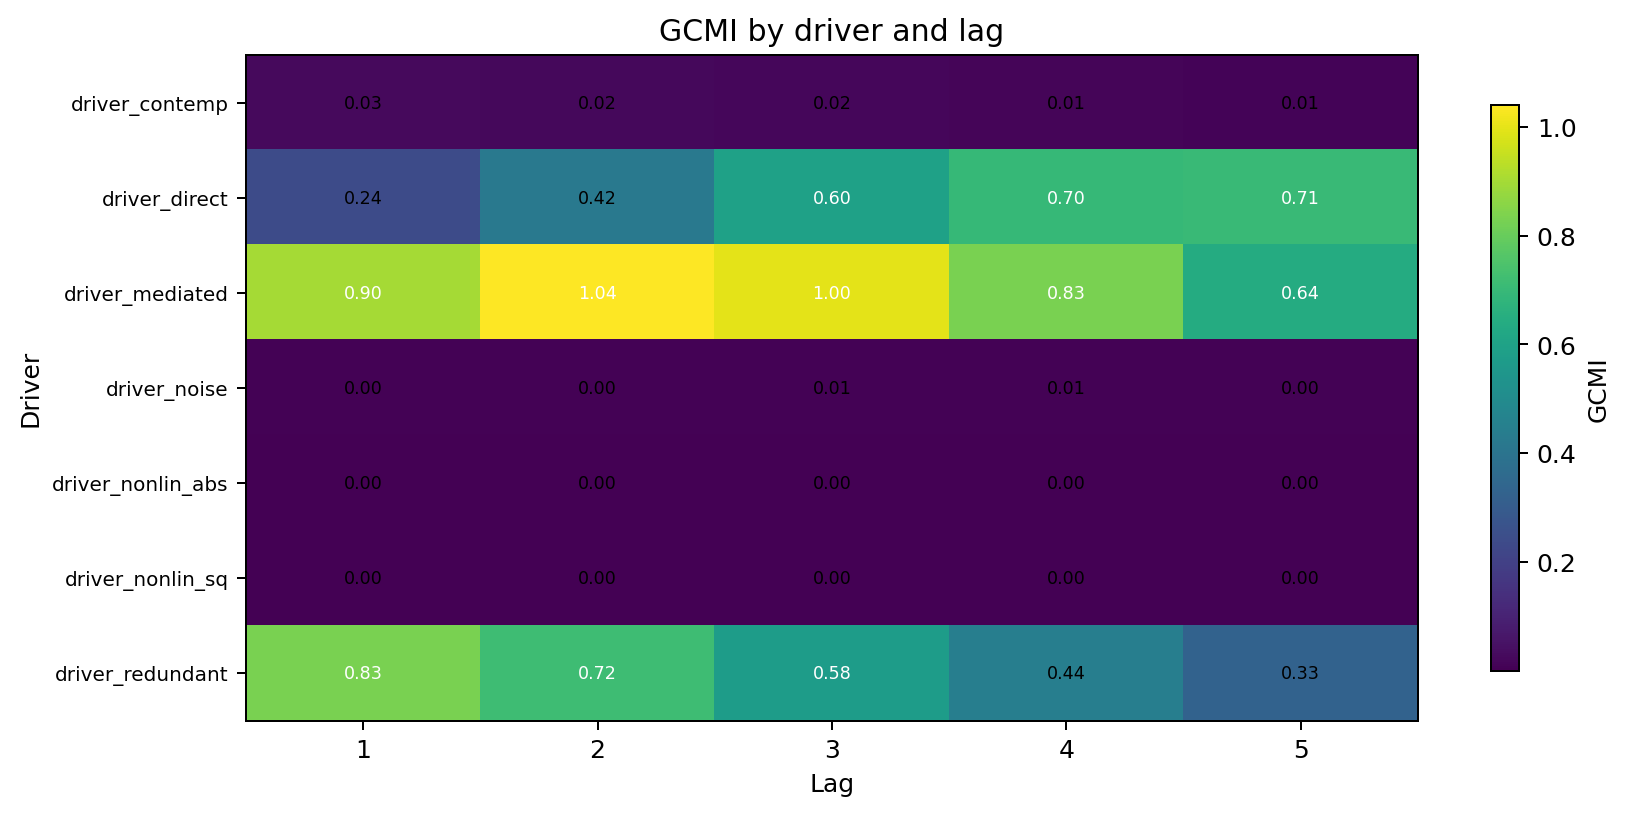

,driver,cross_ami,gcmi
2,driver_mediated,0.7171,1.0399
6,driver_redundant,0.6584,0.8300
1,driver_direct,0.5161,0.7051
0,driver_contemp,0.0427,0.0269
3,driver_noise,0.0283,0.0056
4,driver_nonlin_abs,0.0077,0.0005
5,driver_nonlin_sq,0.0572,0.0004


,lag,cross_ami,gcmi,cross_ami_monotone,gcmi_monotone,cross_ami_abs_delta,gcmi_abs_delta
0,4,0.5161,0.6962,0.5187,0.6962,0.0025,0.0
1,5,0.5055,0.7051,0.5079,0.7051,0.0025,0.0
2,3,0.4208,0.5959,0.4351,0.5959,0.0143,0.0
3,2,0.2968,0.4221,0.3100,0.4221,0.0133,0.0
4,1,0.1760,0.2392,0.1731,0.2392,0.0029,0.0


In [9]:
gcmi_path = FIG_DIR / "section_d_gcmi_heatmap.png"
gcmi_grid = save_metric_heatmap(
    bundle_all,
    metric="gcmi",
    output_path=gcmi_path,
    title="GCMI by driver and lag",
)

transformed_direct = np.sign(drivers["driver_direct"]) * np.log1p(np.abs(drivers["driver_direct"]))
mono_bundle = run_covariant_analysis(
    target,
    {"driver_direct_monotone": transformed_direct},
    methods=["cross_ami", "gcmi"],
    max_lag=MAX_LAG,
    n_surrogates=N_SURROGATES,
    random_state=SEED,
)
mono_frame = summary_table_frame(mono_bundle)
original_direct = summary_all.loc[summary_all["driver"] == "driver_direct", ["lag", "cross_ami", "gcmi"]].copy()
transformed_direct_frame = mono_frame.loc[
    mono_frame["driver"] == "driver_direct_monotone", ["lag", "cross_ami", "gcmi"]
].rename(
    columns={
        "cross_ami": "cross_ami_monotone",
        "gcmi": "gcmi_monotone",
    }
)
monotone_compare = original_direct.merge(transformed_direct_frame, on="lag", how="inner")
monotone_compare["cross_ami_abs_delta"] = (monotone_compare["cross_ami"] - monotone_compare["cross_ami_monotone"]).abs()
monotone_compare["gcmi_abs_delta"] = (monotone_compare["gcmi"] - monotone_compare["gcmi_monotone"]).abs()
write_frame_csv(monotone_compare, output_path=TABLE_DIR / "section_d_monotone_compare.csv")

gcmi_driver_peaks = (
    summary_all.groupby("driver", as_index=False)[["cross_ami", "gcmi"]]
    .max()
    .sort_values("gcmi", ascending=False)
)

display(Image(filename=str(gcmi_path)))
display(gcmi_driver_peaks)
display(monotone_compare)

In [10]:
top_gcmi = gcmi_driver_peaks.iloc[0]
max_gcmi_delta = float(monotone_compare["gcmi_abs_delta"].max())
max_mi_delta = float(monotone_compare["cross_ami_abs_delta"].max())

display(
    Markdown(
        f"**What GCMI adds:** it keeps the same pairwise screening perspective as CrossAMI, but measures dependence "
        f"through a Gaussian-copula transform that is robust to monotone marginal distortions. In this run the strongest "
        f"driver by GCMI was `{top_gcmi['driver']}` with peak GCMI `{top_gcmi['gcmi']:.3f}`. After a monotone transform of "
        f"`driver_direct`, the largest per-lag absolute delta was `{max_gcmi_delta:.4f}` for GCMI versus `{max_mi_delta:.4f}` "
        f"for CrossAMI. The ranking remains pairwise: strong redundant and mediated drivers still score highly until causal "
        f"filtering is applied."
    )
)

**What GCMI adds:** it keeps the same pairwise screening perspective as CrossAMI, but measures dependence through a Gaussian-copula transform that is robust to monotone marginal distortions. In this run the strongest driver by GCMI was `driver_mediated` with peak GCMI `1.040`. After a monotone transform of `driver_direct`, the largest per-lag absolute delta was `0.0000` for GCMI versus `0.0143` for CrossAMI. The ranking remains pairwise: strong redundant and mediated drivers still score highly until causal filtering is applied.

## E — Transfer entropy

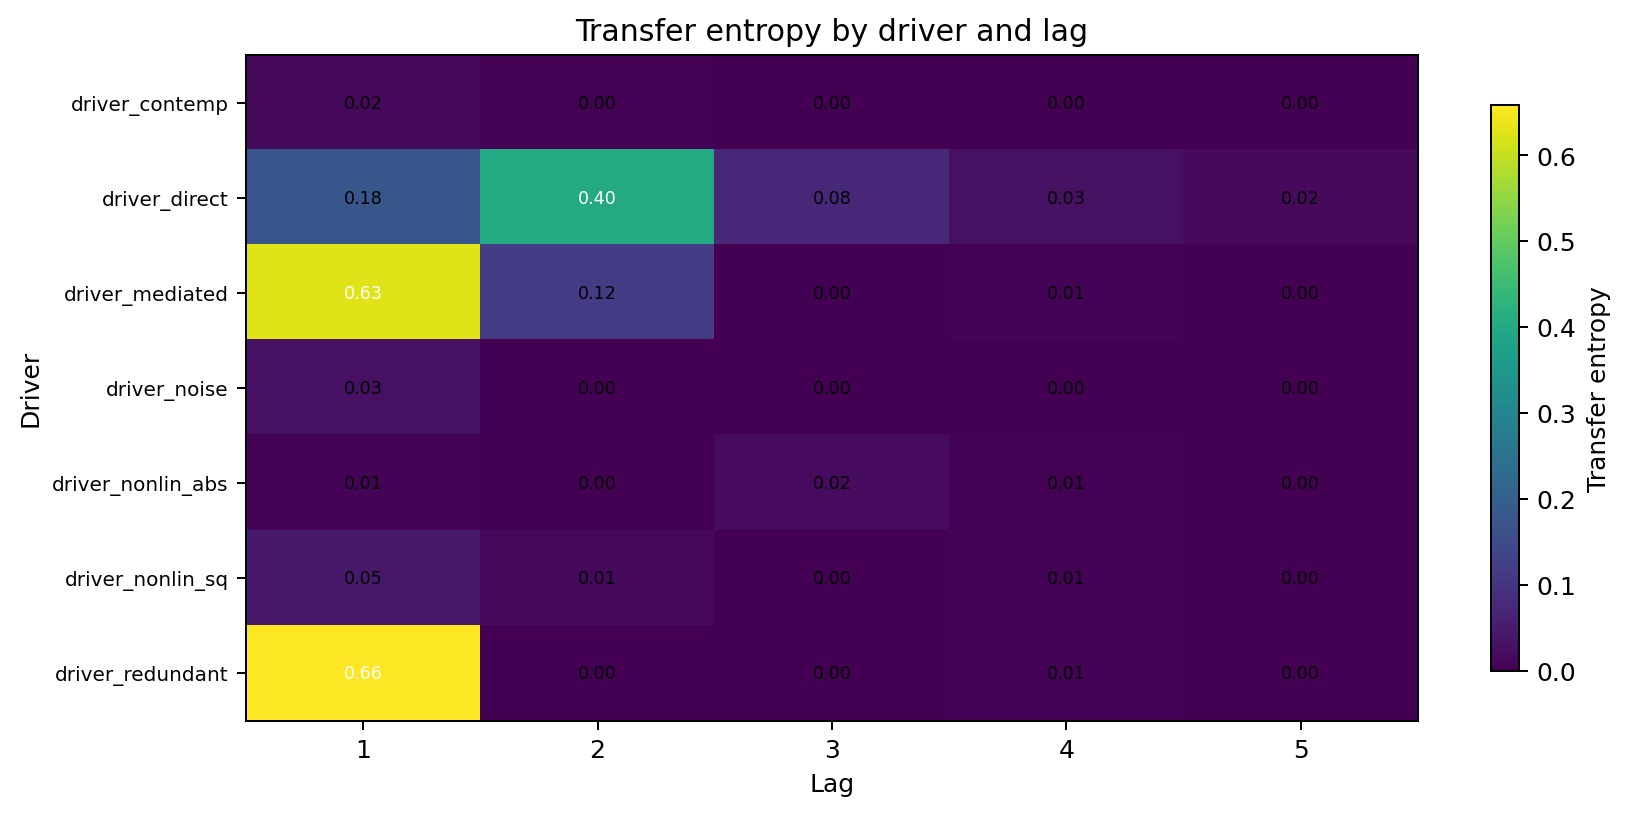

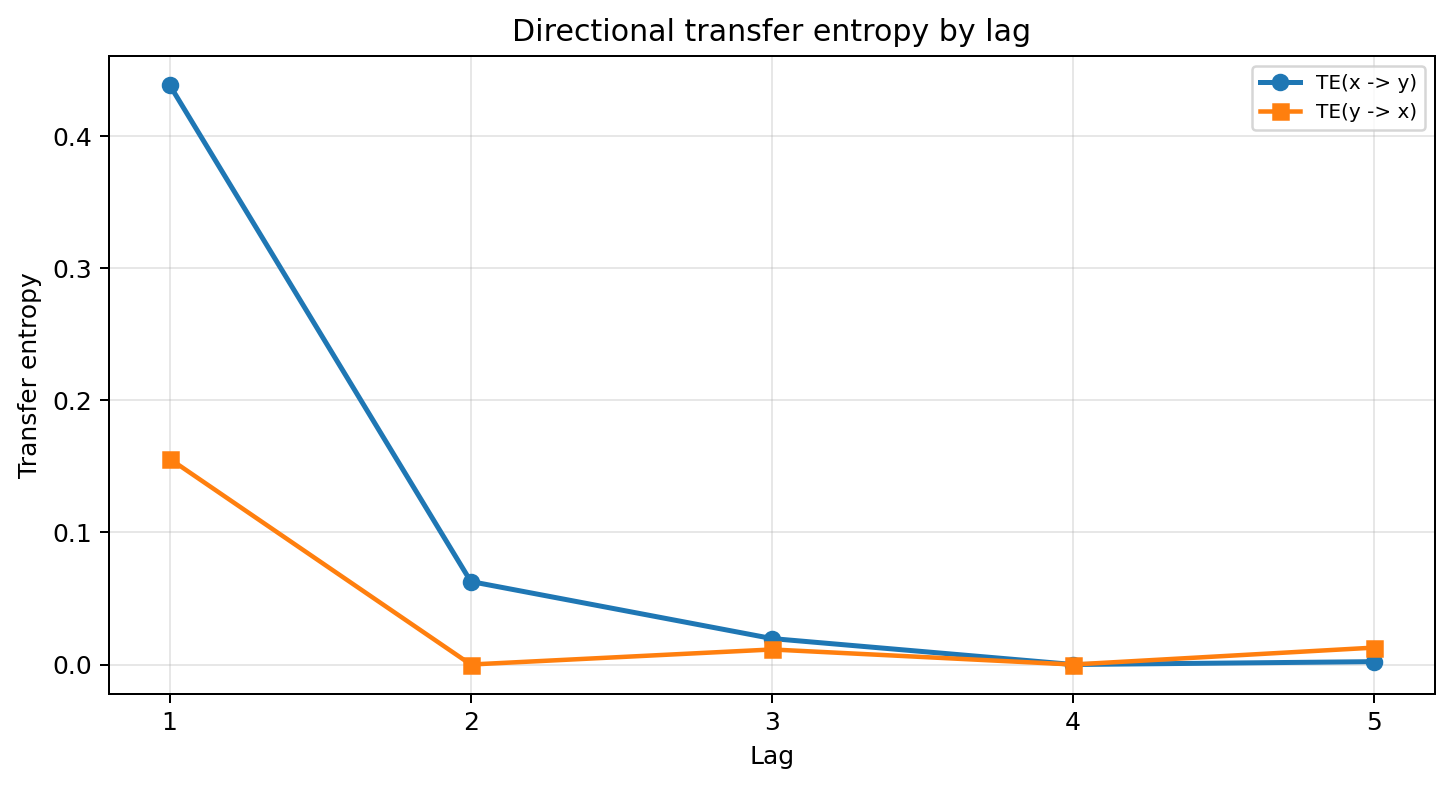

,driver,lag,transfer_entropy,rank,interpretation_tag
2,driver_redundant,1,0.6584,3,directional_informative
3,driver_mediated,1,0.6270,4,causal_confirmed
12,driver_direct,2,0.4027,13,causal_confirmed
14,driver_direct,1,0.1760,15,directional_informative
0,driver_mediated,2,0.1165,1,probably_mediated
10,driver_direct,3,0.0766,11,probably_mediated
16,driver_nonlin_sq,1,0.0455,17,directional_informative
6,driver_direct,4,0.0301,7,probably_mediated
20,driver_noise,1,0.0283,21,directional_informative
32,driver_nonlin_abs,3,0.0186,33,noise_or_weak


In [11]:
te_path = FIG_DIR / "section_e_transfer_entropy_heatmap.png"
te_grid = save_metric_heatmap(
    bundle_all,
    metric="transfer_entropy",
    output_path=te_path,
    title="Transfer entropy by driver and lag",
)

pair_df = generate_directional_pair(n=2000, seed=SEED)
direction_path = FIG_DIR / "section_e_directional_pair.png"
directionality_frame = save_directionality_plot(
    source=pair_df["x"].to_numpy(),
    target=pair_df["y"].to_numpy(),
    output_path=direction_path,
    max_lag=MAX_LAG,
    random_state=SEED,
    source_name="x",
    target_name="y",
)
write_frame_csv(directionality_frame, output_path=TABLE_DIR / "section_e_directional_pair.csv")

te_top = summary_all[
    ["driver", "lag", "transfer_entropy", "rank", "interpretation_tag"]
].sort_values(["transfer_entropy", "lag"], ascending=[False, True]).head(12)
write_frame_csv(te_top, output_path=TABLE_DIR / "section_e_te_top_rows.csv")

display(Image(filename=str(te_path)))
display(Image(filename=str(direction_path)))
display(te_top)

In [12]:
forward_col = "te_x_to_y"
reverse_col = "te_y_to_x"
peak_forward = directionality_frame.sort_values(forward_col, ascending=False).iloc[0]
peak_reverse = directionality_frame.sort_values(reverse_col, ascending=False).iloc[0]
ratio = float(peak_forward[forward_col] / max(float(peak_reverse[reverse_col]), 1e-10))

best_te_driver = te_top.iloc[0]

display(
    Markdown(
        f"**What TE changes:** direction matters. On the auxiliary directional pair, the strongest forward TE occurs at "
        f"lag `{int(peak_forward['lag'])}` with value `{peak_forward[forward_col]:.3f}`, while the strongest reverse TE is "
        f"only `{peak_reverse[reverse_col]:.3f}` (forward/reverse ratio `{ratio:.1f}x`). On the full benchmark, the top TE row "
        f"was `{best_te_driver['driver']} @ lag {int(best_te_driver['lag'])}` with TE `{best_te_driver['transfer_entropy']:.3f}`. "
        f"TE is still `target_only` conditioned in this release, so it is directional but not yet a full multivariate causal filter."
    )
)

**What TE changes:** direction matters. On the auxiliary directional pair, the strongest forward TE occurs at lag `1` with value `0.439`, while the strongest reverse TE is only `0.156` (forward/reverse ratio `2.8x`). On the full benchmark, the top TE row was `driver_redundant @ lag 1` with TE `0.658`. TE is still `target_only` conditioned in this release, so it is directional but not yet a full multivariate causal filter.

## F — PCMCI+

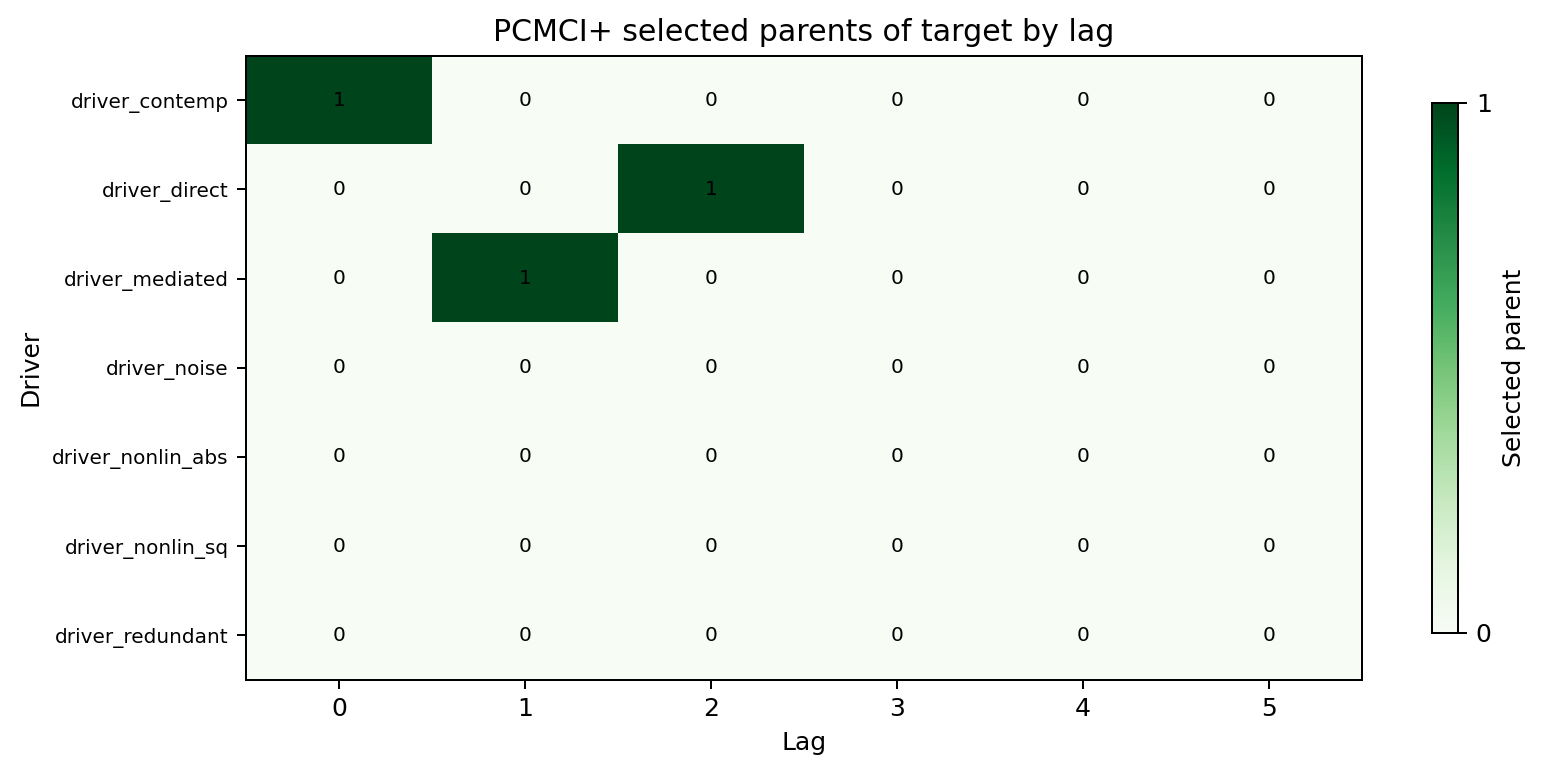

,source,lag
0,driver_contemp,0
1,driver_mediated,1
2,target,1
3,driver_direct,2
4,target,2


In [13]:
if bundle_all.pcmci_graph is None:
    display(Markdown("**PCMCI+ was not available in this environment.**"))
else:
    pcmci_path = FIG_DIR / "section_f_pcmci_heatmap.png"
    pcmci_grid = save_causal_parent_heatmap(
        bundle_all.pcmci_graph,
        target_name=bundle_all.target_name,
        driver_names=bundle_all.driver_names,
        output_path=pcmci_path,
        max_lag=MAX_LAG,
        title="PCMCI+ selected parents of target by lag",
    )
    pcmci_parents = causal_parent_frame(bundle_all.pcmci_graph, target_name=bundle_all.target_name)
    write_frame_csv(pcmci_parents, output_path=TABLE_DIR / "section_f_pcmci_parents.csv")

    display(Image(filename=str(pcmci_path)))
    display(pcmci_parents)


In [14]:
if bundle_all.pcmci_graph is not None:
    pcmci_parents = causal_parent_frame(bundle_all.pcmci_graph, target_name=bundle_all.target_name)
    lagged_exog = pcmci_parents.loc[
        (pcmci_parents["source"] != bundle_all.target_name) & (pcmci_parents["lag"] >= 1)
    ]
    contemp = pcmci_parents.loc[pcmci_parents["lag"] == 0]
    self_parents = pcmci_parents.loc[pcmci_parents["source"] == bundle_all.target_name]
    display(
        Markdown(
            f"**What PCMCI+ filters out:** the selected lagged exogenous parents were "
            f"`{lagged_exog.to_dict(orient='records')}`. Contemporaneous selections were "
            f"`{contemp.to_dict(orient='records')}` and target self-history remained "
            f"`{self_parents.to_dict(orient='records')}`. This is the first section where the redundant driver can be removed "
            f"despite strong pairwise dependence."
        )
    )


**What PCMCI+ filters out:** the selected lagged exogenous parents were `[{'source': 'driver_mediated', 'lag': 1}, {'source': 'driver_direct', 'lag': 2}]`. Contemporaneous selections were `[{'source': 'driver_contemp', 'lag': 0}]` and target self-history remained `[{'source': 'target', 'lag': 1}, {'source': 'target', 'lag': 2}]`. This is the first section where the redundant driver can be removed despite strong pairwise dependence.

## G — PCMCI-AMI

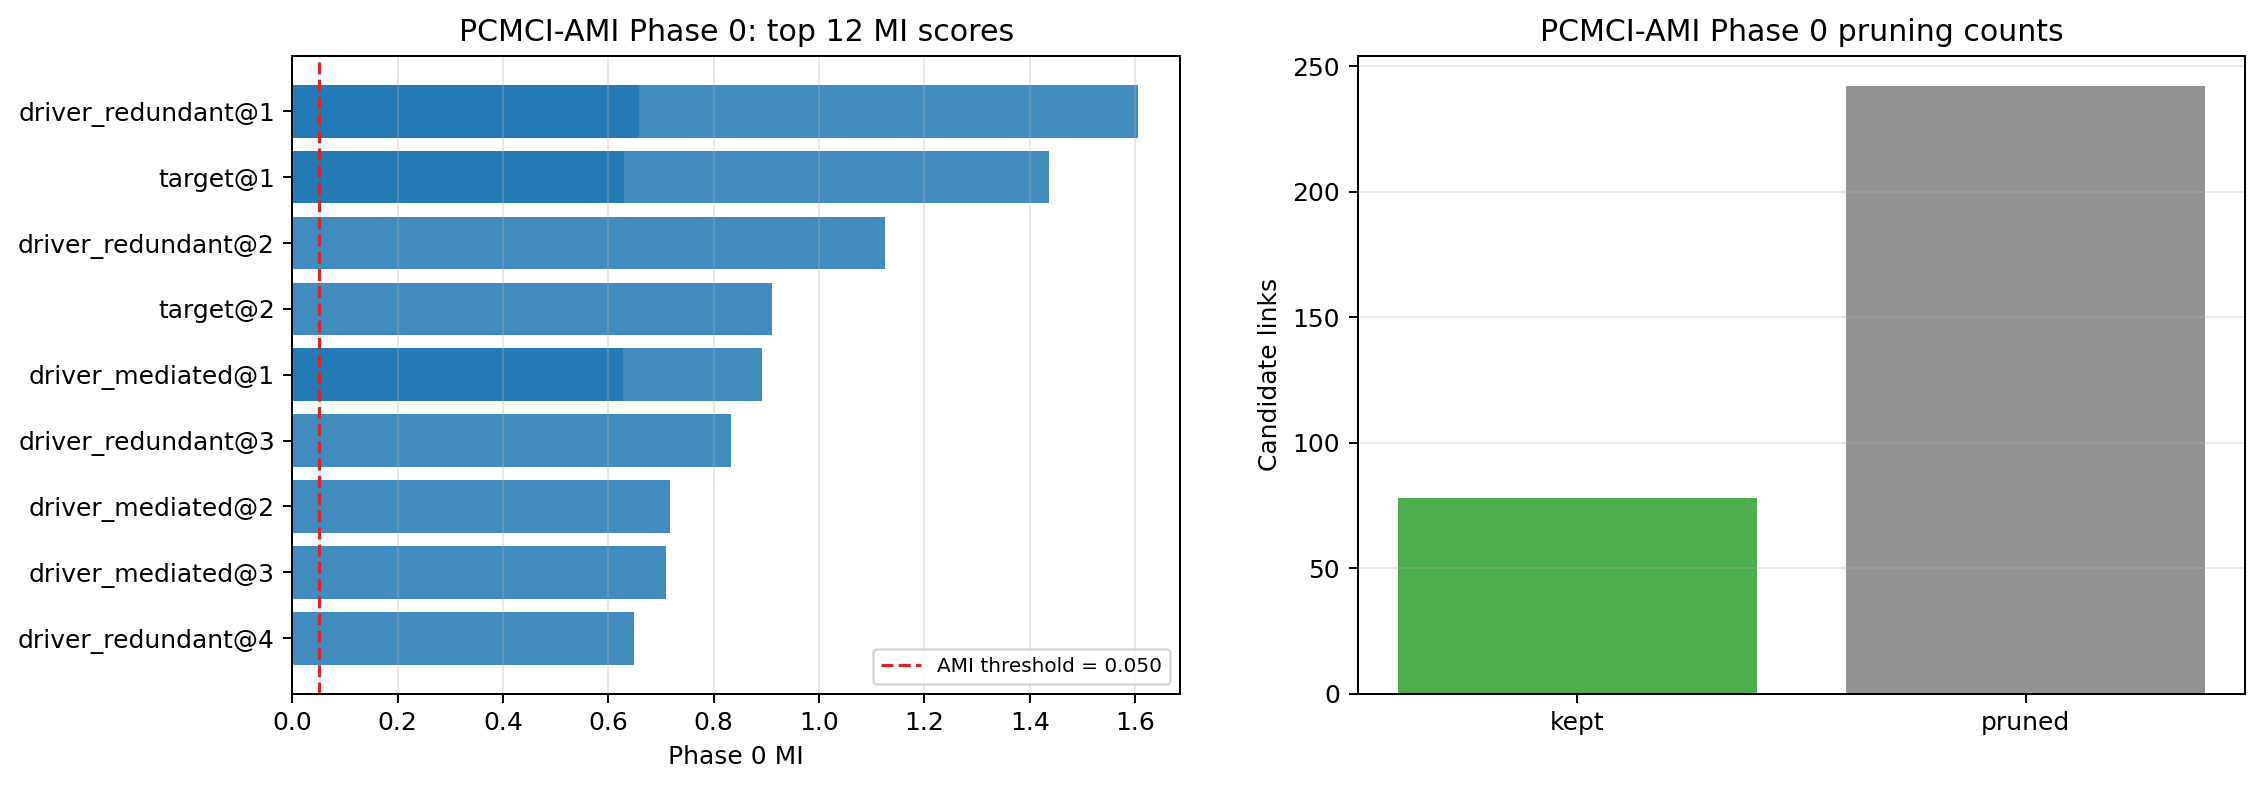

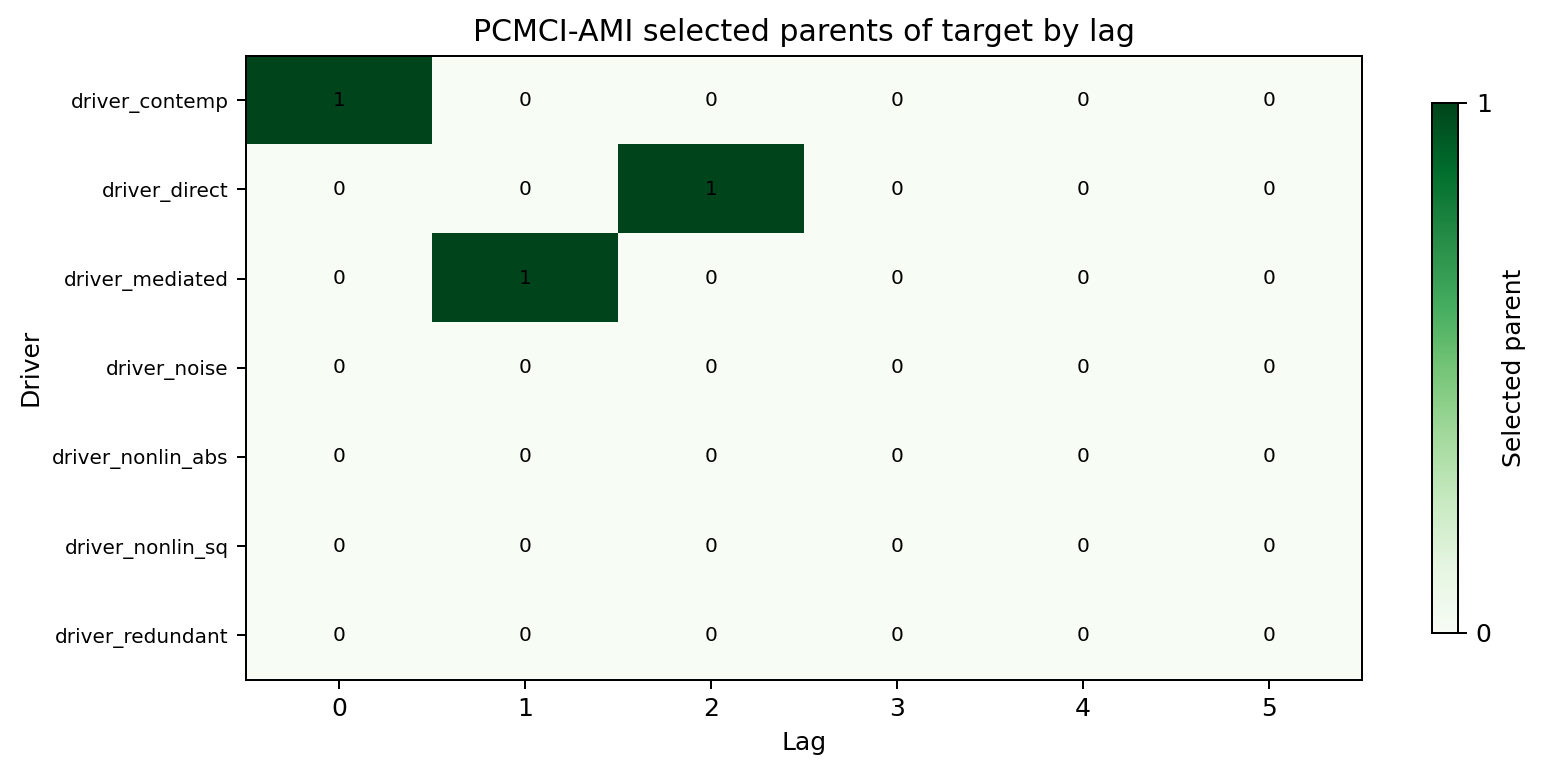

,source,lag,target,mi_value
0,driver_redundant,1,driver_redundant,1.6053
1,target,1,target,1.4363
2,driver_redundant,2,driver_redundant,1.1250
3,target,2,target,0.9103
4,driver_mediated,1,driver_mediated,0.8916
5,driver_redundant,3,driver_redundant,0.8329
6,driver_mediated,2,target,0.7171
7,driver_mediated,3,target,0.7095
8,driver_redundant,1,target,0.6584
9,driver_redundant,4,driver_redundant,0.6486


,source,lag
0,driver_contemp,0
1,driver_mediated,1
2,target,1
3,driver_direct,2


In [15]:
if bundle_all.pcmci_ami_result is None:
    display(Markdown("**PCMCI-AMI was not available in this environment.**"))
else:
    phase0_path = FIG_DIR / "section_g_phase0_overview.png"
    pcmci_ami_path = FIG_DIR / "section_g_pcmci_ami_heatmap.png"

    phase0_frame = save_phase0_overview(
        bundle_all.pcmci_ami_result,
        output_path=phase0_path,
        top_n=12,
    )
    pcmci_ami_grid = save_causal_parent_heatmap(
        bundle_all.pcmci_ami_result.causal_graph,
        target_name=bundle_all.target_name,
        driver_names=bundle_all.driver_names,
        output_path=pcmci_ami_path,
        max_lag=MAX_LAG,
        title="PCMCI-AMI selected parents of target by lag",
    )
    pcmci_ami_parents = causal_parent_frame(
        bundle_all.pcmci_ami_result.causal_graph,
        target_name=bundle_all.target_name,
    )

    write_frame_csv(phase0_frame, output_path=TABLE_DIR / "section_g_phase0_scores.csv")
    write_frame_csv(pcmci_ami_parents, output_path=TABLE_DIR / "section_g_pcmci_ami_parents.csv")

    display(Image(filename=str(phase0_path)))
    display(Image(filename=str(pcmci_ami_path)))
    display(phase0_frame.head(12))
    display(pcmci_ami_parents)


In [16]:
if bundle_all.pcmci_ami_result is not None:
    result = bundle_all.pcmci_ami_result
    pcmci_ami_parents = causal_parent_frame(result.causal_graph, target_name=bundle_all.target_name)
    display(
        Markdown(
            f"**What the hybrid adds:** Phase 0 kept `{result.phase0_kept_count}` candidate links and pruned "
            f"`{result.phase0_pruned_count}` before the PCMCI stage. The final parent set was "
            f"`{pcmci_ami_parents.to_dict(orient='records')}`. This retains the graph-based filtering of PCMCI+ while "
            f"reducing the search space with an AMI screen first."
        )
    )


**What the hybrid adds:** Phase 0 kept `78` candidate links and pruned `242` before the PCMCI stage. The final parent set was `[{'source': 'driver_contemp', 'lag': 0}, {'source': 'driver_mediated', 'lag': 1}, {'source': 'target', 'lag': 1}, {'source': 'driver_direct', 'lag': 2}]`. This retains the graph-based filtering of PCMCI+ while reducing the search space with an AMI screen first.

### Threshold sensitivity check for nonlinear parents

The Phase 0 AMI screen can drop weak nonlinear lagged links when a fixed threshold is too high.

This quick check compares:
- `ami_threshold=0.05` (fixed)
- `ami_threshold=None` (auto threshold from Phase 0 MI distribution)

Focus: whether `driver_nonlin_sq @ lag 1` and `driver_nonlin_abs @ lag 1` survive Phase 0 and appear in the final `parents(target)` set.

In [17]:
from forecastability.adapters.pcmci_ami_adapter import PcmciAmiAdapter

benchmark_df_threshold = generate_covariant_benchmark(n=N_BENCHMARK, seed=SEED)
var_names = ["target", *[c for c in benchmark_df_threshold.columns if c != "target"]]
panel = np.column_stack([benchmark_df_threshold[name].to_numpy() for name in var_names])


def _phase0_kept_lag1(result, source: str) -> bool:
    return any(
        score.target == "target" and score.source == source and score.lag == 1
        for score in result.phase0_mi_scores
    )


def _is_final_parent_lag1(result, source: str) -> bool:
    return (source, 1) in set(result.causal_graph.parents.get("target", []))


threshold_cases = [
    ("fixed_0.05", 0.05),
    ("auto_none", None),
]

rows: list[dict[str, object]] = []
for label, threshold in threshold_cases:
    adapter = PcmciAmiAdapter(ami_threshold=threshold)
    result = adapter.discover_full(
        panel,
        var_names,
        max_lag=MAX_LAG,
        alpha=0.01,
        random_state=SEED,
    )
    parents_target = sorted(result.causal_graph.parents.get("target", []), key=lambda x: (x[1], x[0]))
    rows.append(
        {
            "run": label,
            "configured_threshold": threshold,
            "effective_threshold": result.ami_threshold,
            "phase0_kept": result.phase0_kept_count,
            "phase0_pruned": result.phase0_pruned_count,
            "phase0_keep_nonlin_sq_lag1": _phase0_kept_lag1(result, "driver_nonlin_sq"),
            "phase0_keep_nonlin_abs_lag1": _phase0_kept_lag1(result, "driver_nonlin_abs"),
            "final_parent_nonlin_sq_lag1": _is_final_parent_lag1(result, "driver_nonlin_sq"),
            "final_parent_nonlin_abs_lag1": _is_final_parent_lag1(result, "driver_nonlin_abs"),
            "final_parents_target": parents_target,
        }
    )

threshold_report = pd.DataFrame(rows)
display(threshold_report)

for row in rows:
    print(f"[{row['run']}] parents(target): {row['final_parents_target']}")

,run,configured_threshold,effective_threshold,phase0_kept,phase0_pruned,phase0_keep_nonlin_sq_lag1,phase0_keep_nonlin_abs_lag1,final_parent_nonlin_sq_lag1,final_parent_nonlin_abs_lag1,final_parents_target
0,fixed_0.05,0.05,0.0500,78,242,False,False,False,False,"[(driver_contemp, 0), (driver_mediated, 1), (t..."
1,auto_none,NaN,0.0011,235,85,True,True,True,False,"[(driver_contemp, 0), (driver_mediated, 1), (d..."


[fixed_0.05] parents(target): [('driver_contemp', 0), ('driver_mediated', 1), ('target', 1), ('driver_direct', 2)]
[auto_none] parents(target): [('driver_contemp', 0), ('driver_mediated', 1), ('driver_nonlin_sq', 1), ('target', 1), ('driver_direct', 2)]


## H — Unified interpretation table

In [18]:
interpretation = interpret_covariant_bundle(bundle_all)
role_view = driver_role_frame(interpretation)
rank_view = summary_all[
    [
        "driver",
        "lag",
        "cross_ami",
        "cross_pami",
        "transfer_entropy",
        "gcmi",
        "pcmci_link",
        "pcmci_ami_parent",
        "significance",
        "rank",
        "interpretation_tag",
    ]
].sort_values(["rank", "driver", "lag"]).head(20)

write_frame_csv(role_view, output_path=TABLE_DIR / "section_h_driver_roles.csv")
write_frame_csv(rank_view, output_path=TABLE_DIR / "section_h_top_ranked_rows.csv")

display(rank_view)
display(role_view)

,driver,lag,cross_ami,cross_pami,transfer_entropy,gcmi,pcmci_link,pcmci_ami_parent,significance,rank,interpretation_tag
0,driver_mediated,2,0.7171,0.0332,0.1165,1.0399e+00,NaN,False,above_band,1,probably_mediated
1,driver_mediated,3,0.7095,0.0000,0.0000,9.9541e-01,NaN,False,above_band,2,probably_mediated
2,driver_redundant,1,0.6584,0.6584,0.6584,8.3002e-01,NaN,False,above_band,3,directional_informative
3,driver_mediated,1,0.6270,0.6270,0.6270,8.9849e-01,-->,True,above_band,4,causal_confirmed
4,driver_mediated,4,0.5930,0.0151,0.0067,8.2909e-01,NaN,False,above_band,5,probably_mediated
5,driver_redundant,2,0.5784,0.0016,0.0000,7.1731e-01,NaN,False,above_band,6,probably_mediated
6,driver_direct,4,0.5161,0.0075,0.0301,6.9619e-01,NaN,False,above_band,7,probably_mediated
7,driver_direct,5,0.5055,0.0197,0.0168,7.0507e-01,NaN,False,above_band,8,probably_mediated
8,driver_mediated,5,0.4544,0.0000,0.0008,6.4151e-01,NaN,False,above_band,9,probably_mediated
9,driver_redundant,3,0.4471,0.0000,0.0000,5.7677e-01,NaN,False,above_band,10,probably_mediated


,driver,role,best_lag,methods_supporting,warnings
0,driver_contemp,direct_driver,3,"pcmci, pcmci_ami",transfer_entropy and pCrossAMI are conditioned...
1,driver_direct,direct_driver,4,"cross_ami, gcmi, transfer_entropy, pcmci, pcmc...",transfer_entropy and pCrossAMI are conditioned...
2,driver_mediated,direct_driver,2,"cross_ami, gcmi, transfer_entropy, pcmci, pcmc...",transfer_entropy and pCrossAMI are conditioned...
3,driver_noise,inconclusive,1,-,transfer_entropy and pCrossAMI are conditioned...
4,driver_nonlin_abs,noise_or_weak,1,-,transfer_entropy and pCrossAMI are conditioned...
5,driver_nonlin_sq,nonlinear_driver,2,-,transfer_entropy and pCrossAMI are conditioned...
6,driver_redundant,redundant,1,"cross_ami, gcmi, transfer_entropy",transfer_entropy and pCrossAMI are conditioned...


In [19]:
summary_text = (
    f"**Unified readout:** forecastability=`{interpretation.forecastability_class}`, "
    f"directness=`{interpretation.directness_class}`, primary drivers=`{interpretation.primary_drivers}`, "
    f"modeling regime=`{interpretation.modeling_regime}`."
    "\n\n"
    f"> {interpretation.conditioning_disclaimer}"
)
display(Markdown(summary_text))

**Unified readout:** forecastability=`high`, directness=`medium`, primary drivers=`['driver_contemp', 'driver_direct', 'driver_mediated', 'driver_nonlin_sq']`, modeling regime=`high+medium -> structured exogenous models with caveats`.

> Bundle conditioning scope: CrossMI and GCMI rows are unconditioned pairwise signals (`none`); pCrossAMI and TE rows are `target_only`; only PCMCI+ and PCMCI-AMI are `full_mci`. See section 5A in docs/plan/v0_3_0_covariant_informative_ultimate_plan.md.

## Known limitation: exogenous autohistory is not conditioned out in CrossMI/pCrossAMI/TE—see v0.3.1

This section reproduces the conditioning-scope table directly from the bundle metadata.
The follow-up plan is tracked in
[`docs/plan/v0_3_1_lagged_exogenous_triage_plan.md`](../../docs/plan/v0_3_1_lagged_exogenous_triage_plan.md).

In [20]:
conditioning_view = conditioning_scope_frame(bundle_all)
conditioning_view["v0_3_1_follow_up"] = "docs/plan/v0_3_1_lagged_exogenous_triage_plan.md"
write_frame_csv(conditioning_view, output_path=TABLE_DIR / "section_limitation_conditioning_scope.csv")
conditioning_view

,method,scope,meaning,v0_3_1_follow_up
0,cross_ami,none,Unconditioned pairwise dependence,docs/plan/v0_3_1_lagged_exogenous_triage_plan.md
1,cross_pami,target_only,Conditions on target history only,docs/plan/v0_3_1_lagged_exogenous_triage_plan.md
2,transfer_entropy,target_only,Conditions on target history only,docs/plan/v0_3_1_lagged_exogenous_triage_plan.md
3,gcmi,none,Unconditioned pairwise dependence,docs/plan/v0_3_1_lagged_exogenous_triage_plan.md
4,pcmci,full_mci,Full MCI conditioning on multivariate history,docs/plan/v0_3_1_lagged_exogenous_triage_plan.md
5,pcmci_ami,full_mci,Full MCI conditioning on multivariate history,docs/plan/v0_3_1_lagged_exogenous_triage_plan.md


In [21]:
display(
    Markdown(
        "CrossAMI and GCMI are unconditioned pairwise screens, while CrosspAMI and TE remove only the "
        "target's own history. Only PCMCI+ and PCMCI-AMI reach `full_mci` conditioning in v0.3.0. That is why "
        "the pairwise and target-only sections are useful for screening, but not sufficient on their own for a final "
        "causal claim."
    )
)

CrossAMI and GCMI are unconditioned pairwise screens, while CrosspAMI and TE remove only the target's own history. Only PCMCI+ and PCMCI-AMI reach `full_mci` conditioning in v0.3.0. That is why the pairwise and target-only sections are useful for screening, but not sufficient on their own for a final causal claim.

## Artifact summary

In [22]:
artifact_paths = pd.DataFrame(
    {
        "kind": [
            "figure_root",
            "table_root",
            "full_summary_csv",
            "driver_roles_csv",
            "conditioning_scope_csv",
        ],
        "path": [
            str(FIG_DIR),
            str(TABLE_DIR),
            str(TABLE_DIR / "section_shared_full_summary.csv"),
            str(TABLE_DIR / "section_h_driver_roles.csv"),
            str(TABLE_DIR / "section_limitation_conditioning_scope.csv"),
        ],
    }
)
artifact_paths

,kind,path
0,figure_root,outputs/notebooks/walkthroughs/01_covariant_in...
1,table_root,outputs/notebooks/walkthroughs/01_covariant_in...
2,full_summary_csv,outputs/notebooks/walkthroughs/01_covariant_in...
3,driver_roles_csv,outputs/notebooks/walkthroughs/01_covariant_in...
4,conditioning_scope_csv,outputs/notebooks/walkthroughs/01_covariant_in...
